# Federated Medical Image Classification — Multi-Dataset Experiments

**ResNet18 · CE + Grid-wise Perona-Malik PIDL · Flower SecAgg+ · No DP noise**

---

**Workflow**
1. Clone the project from GitHub
2. Download public Kaggle datasets (no API key needed)
3. Run `flwr run .` for each experiment
4. Download `results/` at the end — push to git from your local PC

| Section | Contents |
|---|---|
| 1 | Clone repo + install dependencies |
| 2 | Download datasets (public, no auth) |
| 3 | Preview dataset structure |
| 4 | Experiment configuration |
| 5 | Run experiment loop |
| 6 | Verify outputs + master summary |
| 7 | Quick plots |
| 8 | Download results |

> **Resume**: runs whose `fl_summary.json` already exists are skipped.  
> **GPU cache** is cleared between runs automatically.

---
## § 1 — Clone Repo + Install Dependencies

In [1]:
# ── Edit your GitHub repo URL here ───────────────────────────────────
GITHUB_REPO = 'https://github.com/PulockDas/medical_fl_pidl.git'
# ──────────────────────────────────────────────────────────────────────

import os, sys
from pathlib import Path

PROJECT_ROOT = Path('/content/medical_fl_pidl')

if not PROJECT_ROOT.exists():
    os.system(f'git clone {GITHUB_REPO} {PROJECT_ROOT}')
else:
    print('Repo already cloned. Pulling latest...')
    os.system(f'git -C {PROJECT_ROOT} pull')

if not PROJECT_ROOT.exists():
    raise RuntimeError(
        f'Clone failed. Check that GITHUB_REPO is set correctly: {GITHUB_REPO!r}'
    )

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)   # flwr run . needs pyproject.toml in cwd
print(f'Working dir: {Path.cwd()}')


Working dir: /content/medical_fl_pidl


In [2]:
# Step 1: upgrade pip + setuptools (Colab ships an old setuptools that
#         breaks editable installs with the Flower build backend)
!pip install -q --upgrade pip setuptools wheel

# Step 2: install all project dependencies from requirements.txt
#         (avoids the pip install -e . build-backend issue entirely)
!pip install -q -r requirements.txt

# Quick sanity check
!python -c "import flwr, torch, kagglehub; print(f'flwr={flwr.__version__}  torch={torch.__version__}  kagglehub OK')"
print('Dependencies installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0.24.0, but you have typer 0.20.1 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.7 which is incompatible.
google-ai-generativelanguage 0.

In [3]:
# Flower version + available CLI commands
import flwr
print('flwr version:', flwr.__version__)
import os
os.system('which flwr')
os.system('flwr --help 2>&1 | head -30')


flwr version: 1.29.0


0

---
## § 2 — Download Datasets

These are **public** Kaggle datasets. `kagglehub` downloads them without any API key or `kaggle.json`.  
Subsequent runs use the local cache — no re-download.

| Dataset | Slug | Structure note |
|---|---|---|
| Brain Tumor MRI | `masoudnickparvar/brain-tumor-mri-dataset` | `Training/class_folders/` — Strategy 1 |
| Lung & Colon Cancer | `andrewmvd/lung-and-colon-cancer-histopathological-images` | Two sub-sets; `COLON_OR_LUNG` chooses which |
| COVID-19 Radiography | `tawsifurrahman/covid19-radiography-database` | `class/images/` nesting — Strategy 5 auto-flattens |

> To swap datasets: edit the slug strings below **and** update `configs/dataset_configs.py`.

In [4]:
import kagglehub
from pathlib import Path as _P
from data.kaggle_loader import find_image_root, preview_dataset_structure

# ── Dataset slugs — edit here to switch datasets ───────────────────────
# Slugs are confirmed public Kaggle datasets; no API key needed.
DATASET_SLUGS = {
    'brain_tumor_mri':           'masoudnickparvar/brain-tumor-mri-dataset',
    'colon_cancer_or_pathology': 'andrewmvd/lung-and-colon-cancer-histopathological-images',
    'covid':                     'tawsifurrahman/covid19-radiography-database',
}

# num_classes = 0  →  auto-detected from the folder count at runtime
DATASET_NUM_CLASSES = {
    'brain_tumor_mri':           0,   # auto (4: glioma, meningioma, notumor, pituitary)
    'colon_cancer_or_pathology': 0,   # auto (2: colon_aca, colon_n)
    'covid':                     0,   # auto (4: COVID, Lung_Opacity, Normal, Viral Pneumonia)
}

SEP = '-' * 62
DATA_ROOTS = {}

# ── Brain Tumor MRI ────────────────────────────────────────────────────
# Structure: root/Training/{glioma,meningioma,notumor,pituitary}  (4 classes)
#            find_image_root Strategy 1 detects Training/ directly.
print(SEP)
print('  brain_tumor_mri')
bt_raw = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
DATA_ROOTS['brain_tumor_mri'] = find_image_root(bt_raw)
print(f'  ImageFolder root: {DATA_ROOTS["brain_tumor_mri"]}')

# ── COVID-19 Radiography Database ─────────────────────────────────────
# Structure: root/COVID-19_Radiography_Dataset/{COVID,Lung_Opacity,Normal,
#            Viral Pneumonia}/images/*.jpg   (images are in a sub-subdir)
#            find_image_root Strategy 5 detects the class/images/ nesting and
#            creates a flat /tmp/ directory with symlinks automatically.
print(SEP)
print('  covid')
covid_raw = kagglehub.dataset_download('tawsifurrahman/covid19-radiography-database')
DATA_ROOTS['covid'] = find_image_root(covid_raw)
print(f'  ImageFolder root: {DATA_ROOTS["covid"]}')

# ── Lung and Colon Cancer Histopathological Images ─────────────────────
# Structure: root/lung_colon_image_set/
#              colon_image_sets/{colon_aca, colon_n}  ← 2 colon classes
#              lung_image_sets/{lung_aca, lung_n, lung_scc}  ← 3 lung classes
# We must choose one subset.  Change COLON_OR_LUNG to 'lung_image_sets' to
# run on lung cancer classes instead.
COLON_OR_LUNG = 'colon_image_sets'   # 'colon_image_sets' | 'lung_image_sets'
print(SEP)
print(f'  colon_cancer_or_pathology  (using {COLON_OR_LUNG})')
lc_raw  = kagglehub.dataset_download('andrewmvd/lung-and-colon-cancer-histopathological-images')
lc_root = _P(lc_raw) / 'lung_colon_image_set' / COLON_OR_LUNG
DATA_ROOTS['colon_cancer_or_pathology'] = str(lc_root)
print(f'  ImageFolder root: {lc_root}')

print(f'\n{SEP}')
print('All datasets ready.')


--------------------------------------------------------------
  brain_tumor_mri
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
[find_image_root] Found (named training split): 'Training'
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  ImageFolder root: /kaggle/input/brain-tumor-mri-dataset/Training
--------------------------------------------------------------
  covid
Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
[find_image_root] Found (class/images/ nesting — auto-flattened via symlinks): 'fl_flat_7a69b95a'
  Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
  ImageFolder root: /tmp/fl_flat_7a69b95a
--------------------------------------------------------------
  colon_cancer_or_pathology  (using colon_image_sets)
Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
  ImageFolder root: /kaggle/input/lung-and-colon-cancer-histopathological-ima

---
## § 3 — Preview Dataset Structure

In [5]:
for ds_name, root in DATA_ROOTS.items():
    print('=' * 55)
    print(f'  {ds_name}')
    print('=' * 55)
    preview_dataset_structure(root, max_depth=3)


  brain_tumor_mri

Training/
├── glioma/                        [1,400 images]
├── meningioma/                    [1,400 images]
├── notumor/                       [1,400 images]
└── pituitary/                     [1,400 images]

  covid

fl_flat_7a69b95a/
├── COVID/                         [3,616 images]
├── Lung_Opacity/                  [6,012 images]
├── Normal/                        [10,192 images]
└── Viral Pneumonia/               [1,345 images]

  colon_cancer_or_pathology

colon_image_sets/
├── colon_aca/                     [5,000 images]
└── colon_n/                       [5,000 images]



---
## § 4 — Experiment Configuration

Edit these values to change FL or PIDL settings.  
All are forwarded as `--run-config` overrides to `flwr run .`.

In [6]:
# ── Experiment grid ────────────────────────────────────────────────────
DATASETS_TO_RUN = list(DATASET_SLUGS.keys())
CLIENT_COUNTS   = [3, 4, 5]

# ── FL training ────────────────────────────────────────────────────────
NUM_SERVER_ROUNDS = 5
LOCAL_EPOCHS      = 2
BATCH_SIZE        = 32
LEARNING_RATE     = 0.001
IMAGE_SIZE        = 224

# ── PIDL regularization ────────────────────────────────────────────────
FEATURE_LAYER    = 'layer2'         # layer1 / layer2 / layer3 / layer4
REGULARIZER_TYPE = 'perona_malik'   # perona_malik | isotropic | none
LAMBDA_PM        = 0.1
USE_GRID_LOSS    = True
GRID_SIZE        = 4
K                = 1.0

# ── SecAgg+ ────────────────────────────────────────────────────────────
SECAGG_MAX_WEIGHT = 1048575    # 2^20 - 1

RANDOM_SEED  = 42
RESULTS_ROOT = PROJECT_ROOT / 'results'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Grid: {len(DATASETS_TO_RUN)} datasets x {len(CLIENT_COUNTS)} client counts = {len(DATASETS_TO_RUN)*len(CLIENT_COUNTS)} runs')
print(f'Results: {RESULTS_ROOT}')


Grid: 3 datasets x 3 client counts = 9 runs
Results: /content/medical_fl_pidl/results


---
## § 5 — Experiment Loop

Calls `flwr run .` as a subprocess for each (dataset, num_clients) pair.  
The server writes all output files to `log_dir` automatically.  
**Already-completed runs are skipped** (resume support).

In [7]:
import gc, json, os, time, torch
from flwr.simulation import run_simulation

# Import apps once — Python caches them; safe to call run_simulation in a loop
from federated.server_app import app as _server_app
from federated.client_app import app as _client_app


def run_experiment(ds_name: str, num_clients: int, resume: bool = True) -> dict:
    log_dir = RESULTS_ROOT / ds_name / f'{num_clients}_clients'
    status  = dict(ds_name=ds_name, num_clients=num_clients,
                   log_dir=str(log_dir), skipped=False, success=False)

    if resume and (log_dir / 'fl_summary.json').exists():
        print(f'  [SKIP] {ds_name} / {num_clients}c \u2014 already done.')
        status.update(skipped=True, success=True)
        return status

    log_dir.mkdir(parents=True, exist_ok=True)
    recon = max(1, num_clients - 1)

    # Build config dict (all strings — _parse_run_config casts them)
    run_cfg = {
        'dataset_name':                    ds_name,
        'data_root':                       str(DATA_ROOTS[ds_name]),
        'num_classes':                     str(DATASET_NUM_CLASSES.get(ds_name, 0)),
        'num_clients':                     str(num_clients),
        'min_fit_clients':                 str(num_clients),
        'num_server_rounds':               str(NUM_SERVER_ROUNDS),
        'local_epochs':                    str(LOCAL_EPOCHS),
        'batch_size':                      str(BATCH_SIZE),
        'learning_rate':                   str(LEARNING_RATE),
        'image_size':                      str(IMAGE_SIZE),
        'feature_layer':                   FEATURE_LAYER,
        'regularizer_type':                REGULARIZER_TYPE,
        'lambda_pm':                       str(LAMBDA_PM),
        'use_grid_loss':                   str(USE_GRID_LOSS).lower(),
        'grid_size':                       str(GRID_SIZE),
        'k':                               str(K),
        'random_seed':                     str(RANDOM_SEED),
        'log_dir':                         str(log_dir),
        'secagg_num_shares':               str(num_clients),
        'secagg_reconstruction_threshold': str(recon),
        'secagg_max_weight':               str(SECAGG_MAX_WEIGHT),
    }

    # Inject config via env var — Ray workers inherit it from the parent process.
    # _parse_run_config() in server_app.py and client_app.py reads FL_RUN_OVERRIDE
    # and merges it on top of pyproject.toml defaults (Flower 1.29 compatible).
    os.environ['FL_RUN_OVERRIDE'] = json.dumps(run_cfg)

    gpu_frac    = 0.5 if torch.cuda.is_available() else 0.0
    backend_cfg = {'client_resources': {'num_cpus': 2, 'num_gpus': gpu_frac}}

    print(f'  [RUN ] {ds_name} / {num_clients}c  ->  {log_dir.name}/')
    t0 = time.time()
    try:
        run_simulation(
            server_app    = _server_app,
            client_app    = _client_app,
            num_supernodes= num_clients,
            backend_config= backend_cfg,
        )
        elapsed = time.time() - t0
        print(f'  [OK  ] {elapsed:.0f}s')
        status['success'] = True
    except Exception as exc:
        elapsed = time.time() - t0
        print(f'  [FAIL] after {elapsed:.0f}s: {exc}')
        import traceback; traceback.print_exc()
    finally:
        os.environ.pop('FL_RUN_OVERRIDE', None)   # clean up after each run

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return status


print('run_experiment() defined.')

run_experiment() defined.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# ── Main loop ──────────────────────────────────────────────────────────
run_log = []
total, done = len(DATASETS_TO_RUN) * len(CLIENT_COUNTS), 0
t_total = time.time()

for ds in DATASETS_TO_RUN:
    if ds not in DATA_ROOTS:
        print(f'[WARN] No data root for {ds} — skipping.')
        continue
    for nc in CLIENT_COUNTS:
        done += 1
        print(f'\n--- Run {done}/{total}  |  {ds}  |  {nc} clients ---')
        run_log.append(run_experiment(ds, nc, resume=True))

elapsed = time.time() - t_total
ok  = sum(1 for r in run_log if r['success'] and not r['skipped'])
skp = sum(1 for r in run_log if r['skipped'])
err = sum(1 for r in run_log if not r['success'])
print(f'\nDone in {elapsed/60:.1f} min  |  OK={ok}  skipped={skp}  failed={err}')



            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
DEBUG:flwr:backend_config: {'client_resources': {'num_cpus': 2, 'num_gpus': 0.5}}
DEBUG:flwr:Asyncio event loop already running.



--- Run 1/9  |  brain_tumor_mri  |  3 clients ---
  [RUN ] brain_tumor_mri / 3c  ->  3_clients/
[Server] Device: cuda  |  Log dir: /content/medical_fl_pidl/results/brain_tumor_mri/3_clients


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[task] Building federated data for 3 clients from: /kaggle/input/brain-tumor-mri-dataset/Training
[build_federated_dataloaders] Loading ImageFolder from '/kaggle/input/brain-tumor-mri-dataset/Training' …
  → 5,600 images  |  4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  → Grayscale source detected. Images will be converted to 3-channel RGB.
  → Split: 4,480 train  |  1,120 test  (stratified, seed=42)
  → Partitioning (iid): client 0: 1,496  |  client 1: 1,492  |  client 2: 1,492
[dataset_utils] Summary saved → /content/medical_fl_pidl/results/brain_tumor_mri/3_clients/dataset_summary.json
[build_federated_dataloaders] Done. 3 client loaders + 1 test loader ready.

[Server] Dataset  : brain_tumor_mri  (4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary'])
[Server] Test set : 1120 samples


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

INFO :      aggregate_fit: received 5 results and 0 failures
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
INFO :      fit progress: (5, 0.2914471013971798, {'accuracy': 0.8993621545003544, 'num_samples': 4233, 'f1_macro': 0.9033393853689027, 'balanced_accuracy': 0.9151114717312272, 'ece': 0.02642770577992158}, 2583.635987616999)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow

[Server Eval] Round   5 | Loss: 0.2914  Acc: 89.94%  N=4233


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 2711.37s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.561015874055889
INFO :      		round 2: 0.8098859775440929
INFO :      		round 3: 0.5193720775492051
INFO :      		round 4: 0.4806366768143517
INFO :      		round 5: 0.2914471013971798
INFO :      	History (loss, centralized):
INFO :      		round 0: 3.131908379349054
INFO :      		round 1: 1.561015874055889
INFO :      		round 2: 0.8098859775440929
INFO :      		round 3: 0.5193720775492051
INFO :      		round 4: 0.4806366768143517
INFO :      		round 5: 0.2914471013971798
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.073706591070163),
INFO :      	              (1, 0.23553035672100164),
INFO :      	              (2, 0.6489487361209544),
INFO :      	              (3, 0.8008504606661941),
INFO :      	              (4, 0.8067564375147649),
INF

Round   5 | Train Acc: 85.86%  Loss: 0.3909  PIDL: 0.025158 | Client Val Acc: 89.94%  Loss: 0.2914 |  Server Acc: 89.94% | Elapsed: 536.9s
  [OK  ] 2759s

Done in 275.5 min  |  OK=9  skipped=0  failed=0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## § 6 — Verify Outputs + Master Summary

In [9]:
import pandas as pd
from pathlib import Path

EXPECTED = [
    'fl_rounds.csv', 'fl_summary.json',
    'per_class_metrics.csv', 'config.json',
    'dataset_summary.json', 'round_metrics.jsonl',
]

print(f'  {"Run":<38}  {"  ".join(f[:10] for f in EXPECTED)}')
print('  ' + '-' * 90)
for r in run_log:
    d = Path(r['log_dir'])
    c = ['OK' if (d / f).exists() else '--' for f in EXPECTED]
    print(f'  {r["ds_name"][:18]}/{r["num_clients"]}c   {"  ".join(c)}')


  Run                                     fl_rounds.  fl_summary  per_class_  config.jso  dataset_su  round_metr
  ------------------------------------------------------------------------------------------
  brain_tumor_mri/3c   OK  --  OK  OK  OK  OK
  brain_tumor_mri/4c   OK  --  OK  OK  OK  OK
  brain_tumor_mri/5c   OK  --  OK  OK  OK  OK
  colon_cancer_or_pa/3c   OK  --  OK  OK  OK  OK
  colon_cancer_or_pa/4c   OK  --  OK  OK  OK  OK
  colon_cancer_or_pa/5c   OK  --  OK  OK  OK  OK
  covid/3c   OK  --  OK  OK  OK  OK
  covid/4c   OK  --  OK  OK  OK  OK
  covid/5c   OK  --  OK  OK  OK  OK


In [10]:
# Build master_summary.csv from fl_summary.json files
rows = []
for ds in DATASETS_TO_RUN:
    for nc in CLIENT_COUNTS:
        p = RESULTS_ROOT / ds / f'{nc}_clients' / 'fl_summary.json'
        if not p.exists(): continue
        s = json.load(open(p))
        s.update(dataset_name=ds, num_clients=nc)
        rows.append(s)

if rows:
    master = pd.DataFrame(rows)
    master.to_csv(RESULTS_ROOT / 'master_summary.csv', index=False)
    cols = ['dataset_name', 'num_clients', 'best_accuracy', 'best_macro_f1', 'final_ece']
    avail = [c for c in cols if c in master.columns]
    print(master[avail].to_string(index=False, float_format='{:.4f}'.format))
else:
    print('No completed runs yet.')


No completed runs yet.


---
## § 7 — Quick Plots

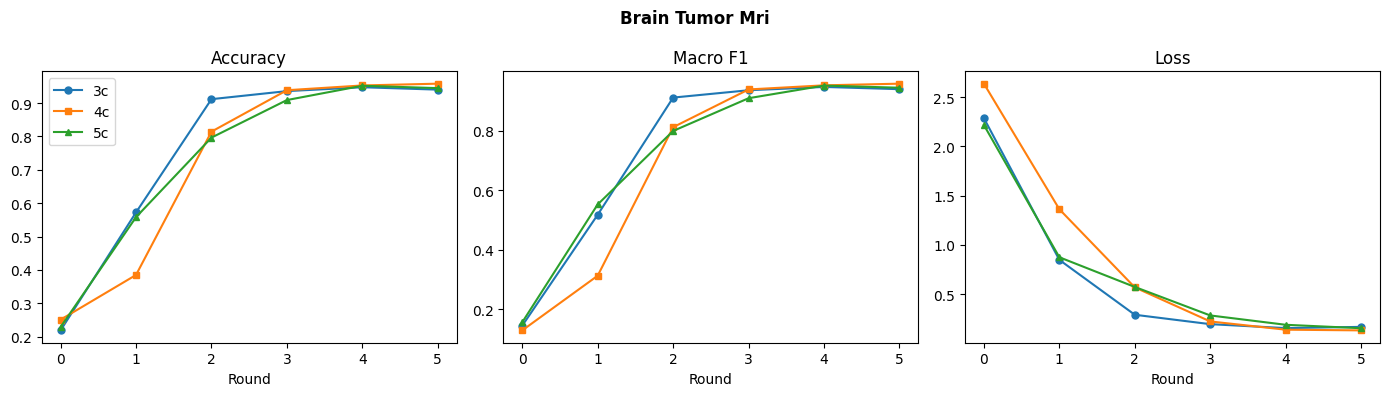

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


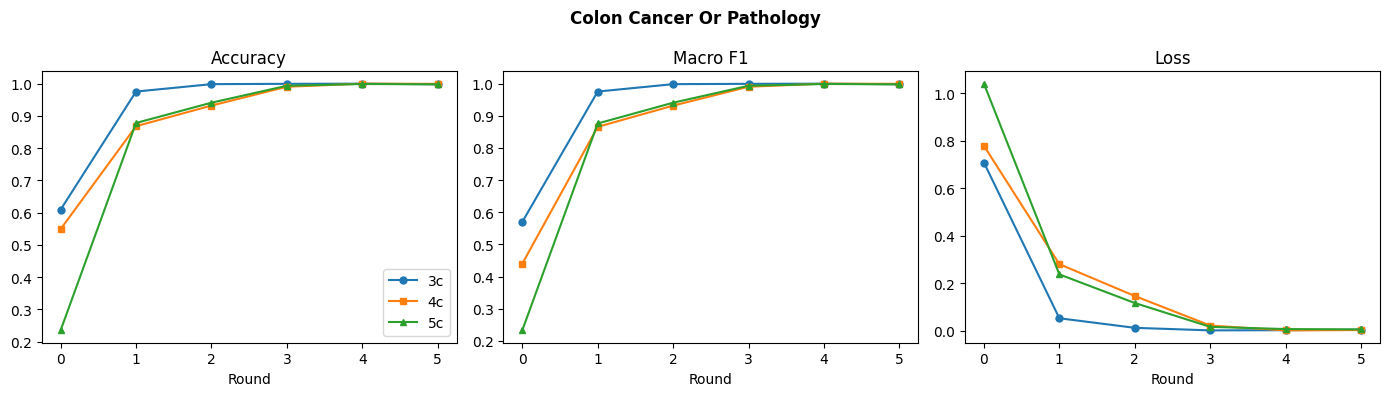

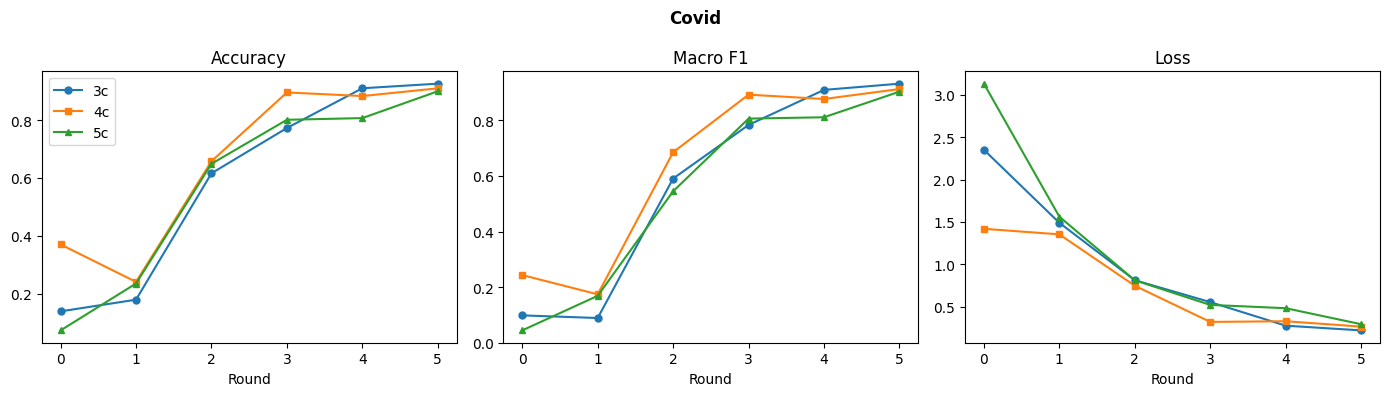

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLORS  = {3: '#1f77b4', 4: '#ff7f0e', 5: '#2ca02c'}
MARKERS = {3: 'o', 4: 's', 5: '^'}

# ── Per-round curves ────────────────────────────────────────────────────
for ds in DATASETS_TO_RUN:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(ds.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    for nc in CLIENT_COUNTS:
        csv = RESULTS_ROOT / ds / f'{nc}_clients' / 'fl_rounds.csv'
        if not csv.exists(): continue
        df = pd.read_csv(csv)
        for ax, col, title in zip(
            axes,
            ['global_test_acc', 'f1_macro', 'global_test_loss'],
            ['Accuracy', 'Macro F1', 'Loss'],
        ):
            if col not in df.columns: continue
            ax.plot(df['round'], df[col], color=COLORS[nc],
                    marker=MARKERS[nc], label=f'{nc}c', markersize=5)
            ax.set_title(title); ax.set_xlabel('Round')
            ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / ds / 'curves.png', dpi=150, bbox_inches='tight')
    plt.show()


In [12]:
# ── Final accuracy + F1 bar charts ─────────────────────────────────────
if 'master' in dir() and not master.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, col, title in zip(
        axes,
        ['best_accuracy', 'best_macro_f1'],
        ['Best Accuracy', 'Best Macro F1'],
    ):
        if col not in master.columns: continue
        pivot = (
            master[['dataset_name', 'num_clients', col]]
            .assign(num_clients=lambda d: d['num_clients'].astype(str) + 'c')
            .pivot(index='dataset_name', columns='num_clients', values=col)
        )
        pivot.plot(kind='bar', ax=ax, colormap='tab10',
                   edgecolor='black', linewidth=0.5, width=0.7)
        ax.set_title(title, fontweight='bold')
        ax.set_ylim(0, 1.08); ax.set_xlabel('')
        ax.set_xticklabels([x.replace('_', '\n') for x in pivot.index], rotation=0)
        for ctr in ax.containers:
            ax.bar_label(ctr, fmt='%.3f', fontsize=7, padding=2)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'final_bars.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## § 8 — Download Results

Zip the `results/` folder and download it to your local machine.  
Then `git add results/ && git commit && git push` from your PC.

In [13]:
# Zip results/ and trigger browser download
!zip -r /content/fl_results.zip {RESULTS_ROOT}

from google.colab import files
files.download('/content/fl_results.zip')
print('Download started. Save the zip, unzip into your local repo, then push to git.')


  adding: content/medical_fl_pidl/results/ (stored 0%)
  adding: content/medical_fl_pidl/results/covid/ (stored 0%)
  adding: content/medical_fl_pidl/results/covid/3_clients/ (stored 0%)
  adding: content/medical_fl_pidl/results/covid/3_clients/dataset_summary.json (deflated 68%)
  adding: content/medical_fl_pidl/results/covid/3_clients/config.json (deflated 46%)
  adding: content/medical_fl_pidl/results/covid/3_clients/fl_rounds.csv (deflated 55%)
  adding: content/medical_fl_pidl/results/covid/3_clients/round_metrics.jsonl (deflated 74%)
  adding: content/medical_fl_pidl/results/covid/3_clients/per_class_metrics.csv (deflated 57%)
  adding: content/medical_fl_pidl/results/covid/5_clients/ (stored 0%)
  adding: content/medical_fl_pidl/results/covid/5_clients/dataset_summary.json (deflated 72%)
  adding: content/medical_fl_pidl/results/covid/5_clients/config.json (deflated 46%)
  adding: content/medical_fl_pidl/results/covid/5_clients/fl_rounds.csv (deflated 55%)
  adding: content/medi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started. Save the zip, unzip into your local repo, then push to git.


---
## End

**Local git workflow after downloading:**
```bash
cd medical_fl_pidl/
unzip ~/Downloads/fl_results.zip -d .
git add results/
git commit -m 'add experiment results'
git push
```

Then open `02_result_analysis_and_plots.ipynb` in Colab to generate publication-quality figures from the saved results.